In [2]:
# ==============================
# ADVANCED EDA
# Store Sales Dataset
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("cleaned_store_sales_data.csv")

In [5]:
# -----------------------------
# Dataset Overview
# -----------------------------
print(df.head())

  Customer ID Customer Name Last Name Date of Birth     Sales  Year  \
0  CUST000001        Curtis    Krause      29-11-73   3344.69  2023   
1  CUST000002        Jeremy    Foster      30-08-87  37094.41  2022   
2  CUST000003         Ariel    Mccann      15-12-80  35501.08  2023   
3  CUST000004       Colleen   Maynard      23-05-89   8969.33  2021   
4  CUST000005          Gina    Holden      31-12-57  35530.44  2021   

  Outlet Type City Type              Category of Goods Region  ... Ship Date  \
0       Large    Tier 1                      Fast Food   East  ...  18-04-20   
1      Medium    Tier 2                      Fast Food   East  ...  11-01-21   
2       Large   Village            Electric Appliances  South  ...  16-08-20   
3      Medium   Village                 Dairy Products   East  ...  16-10-21   
4       Small   Village  Sessional Fruits & Vegetables   West  ...  25-01-19   

        Ship Mode        State Postal Code  Product ID Sub-Category  \
0        Same Day  We

In [6]:
print("\nShape")
print(df.shape)


Shape
(100000, 25)


In [7]:
print("\nColumns")
print(df.columns)


Columns
Index(['Customer ID', 'Customer Name', 'Last Name', 'Date of Birth', 'Sales',
       'Year', 'Outlet Type', 'City Type', 'Category of Goods', 'Region',
       'Country', 'Segment', 'Sales Date', 'Order ID', 'Order Date',
       'Ship Date', 'Ship Mode', 'State', 'Postal Code', 'Product ID',
       'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [8]:
print("\nData Types")
print(df.dtypes)


Data Types
Customer ID           object
Customer Name         object
Last Name             object
Date of Birth         object
Sales                float64
Year                   int64
Outlet Type           object
City Type             object
Category of Goods     object
Region                object
Country               object
Segment               object
Sales Date            object
Order ID              object
Order Date            object
Ship Date             object
Ship Mode             object
State                 object
Postal Code            int64
Product ID            object
Sub-Category          object
Product Name          object
Quantity               int64
Discount             float64
Profit               float64
dtype: object


In [9]:
# -----------------------------
# Missing Values
# -----------------------------
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Customer ID          0
Customer Name        0
Last Name            0
Date of Birth        0
Sales                0
Year                 0
Outlet Type          0
City Type            0
Category of Goods    0
Region               0
Country              0
Segment              0
Sales Date           0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
State                0
Postal Code          0
Product ID           0
Sub-Category         0
Product Name         0
Quantity             0
Discount             0
Profit               0
dtype: int64


In [10]:
# -----------------------------
# Duplicate Records
# -----------------------------
print("\nDuplicate Rows")
print(df.duplicated().sum())


Duplicate Rows
0


In [12]:
# -----------------------------
# Convert Date Columns
# -----------------------------
date_cols = [
    "Date of Birth",
    "Sales Date",
    "Order Date",
    "Ship Date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [13]:
# -----------------------------
# Statistical Summary
# -----------------------------
print(df.describe())

                    Date of Birth          Sales           Year  \
count                      100000  100000.000000  100000.000000   
mean   2022-05-30 19:33:59.328000   25084.410142    2020.999910   
min           1976-01-01 00:00:00     100.570000    2019.000000   
25%           1993-04-07 00:00:00   12618.030000    2020.000000   
50%           2010-06-25 12:00:00   25134.695000    2021.000000   
75%           2058-12-27 00:00:00   37575.850000    2022.000000   
max           2075-12-31 00:00:00   49999.890000    2023.000000   
std                           NaN   14403.187686       1.413757   

                          Sales Date                     Order Date  \
count                         100000                         100000   
mean   2021-07-02 21:09:12.095999744  2021-07-01 22:12:19.007999744   
min              2019-01-01 00:00:00            2019-01-01 00:00:00   
25%              2020-04-04 00:00:00            2020-04-01 00:00:00   
50%              2021-06-30 00:00:00     

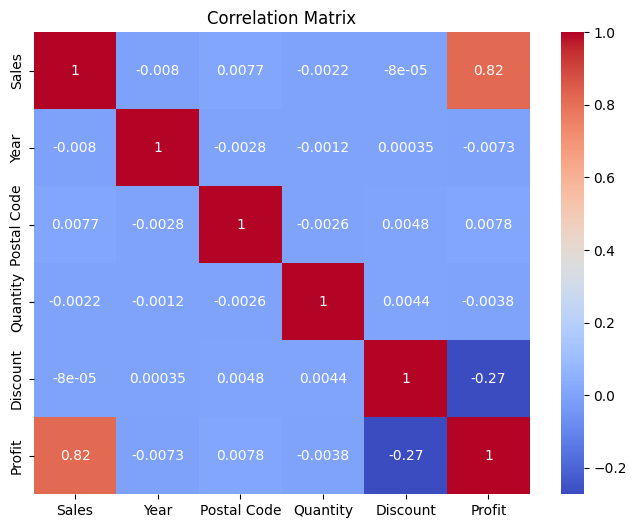

In [14]:
# -----------------------------
# Correlation Matrix
# -----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

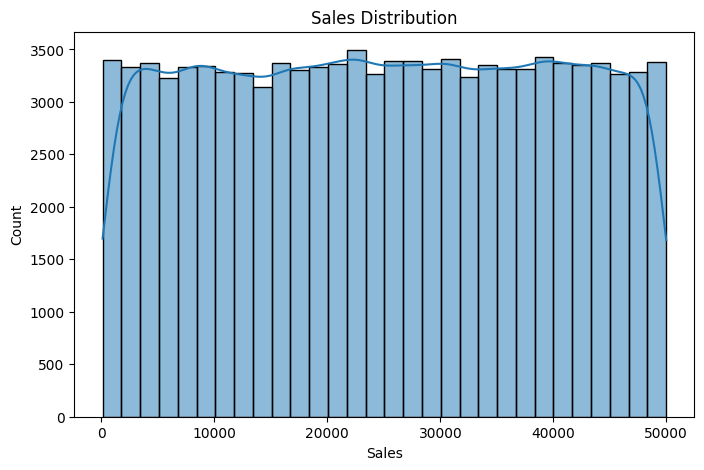

In [15]:
# -----------------------------
# Sales Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

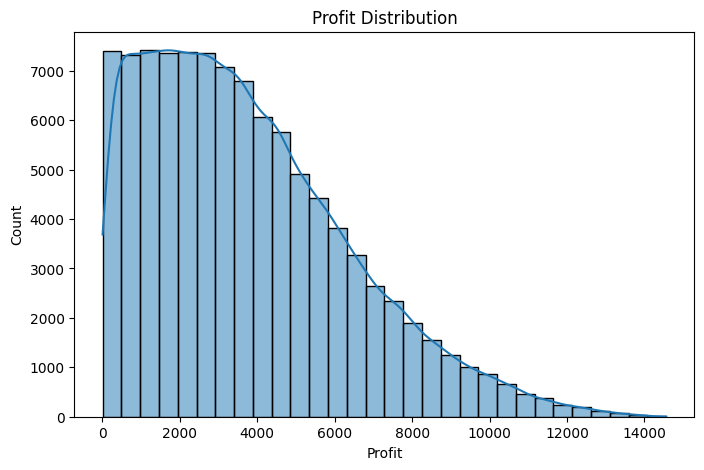

In [16]:
# -----------------------------
# Profit Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["Profit"], bins=30, kde=True)
plt.title("Profit Distribution")
plt.show()

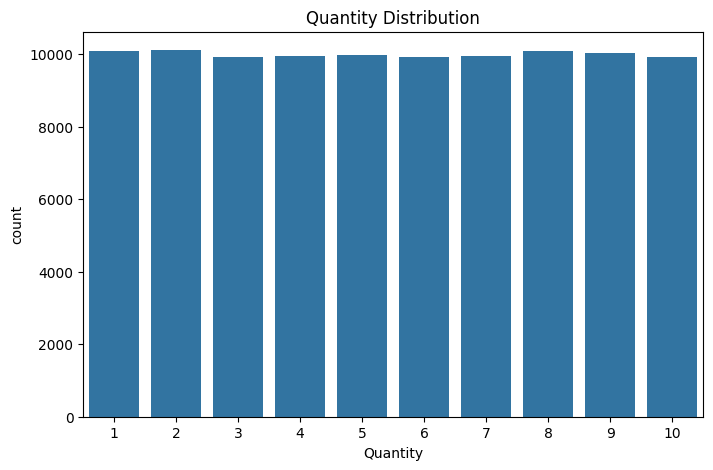

In [17]:
# -----------------------------
# Quantity Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.countplot(x="Quantity", data=df)
plt.title("Quantity Distribution")
plt.show()

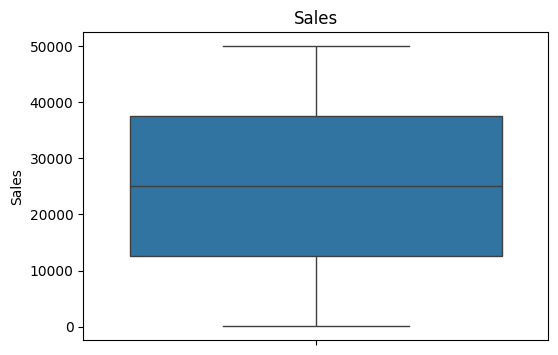

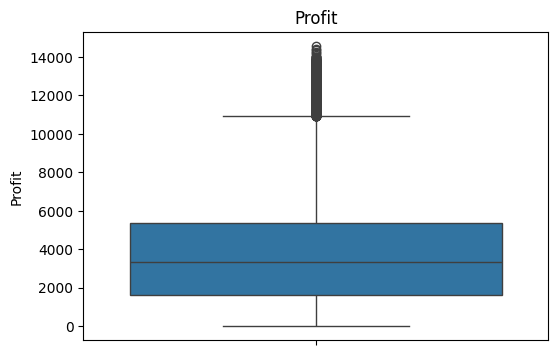

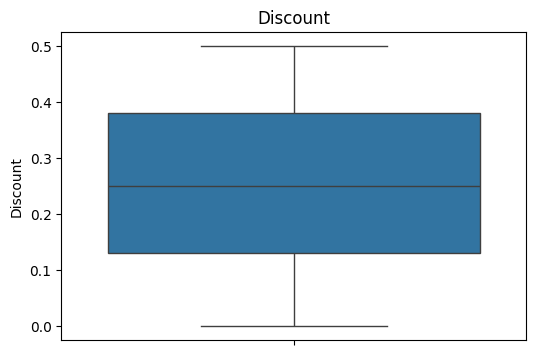

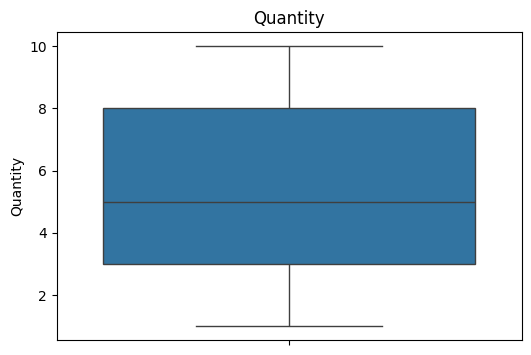

In [18]:
# -----------------------------
# Boxplots
# -----------------------------
numeric = ["Sales","Profit","Discount","Quantity"]

for col in numeric:

    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

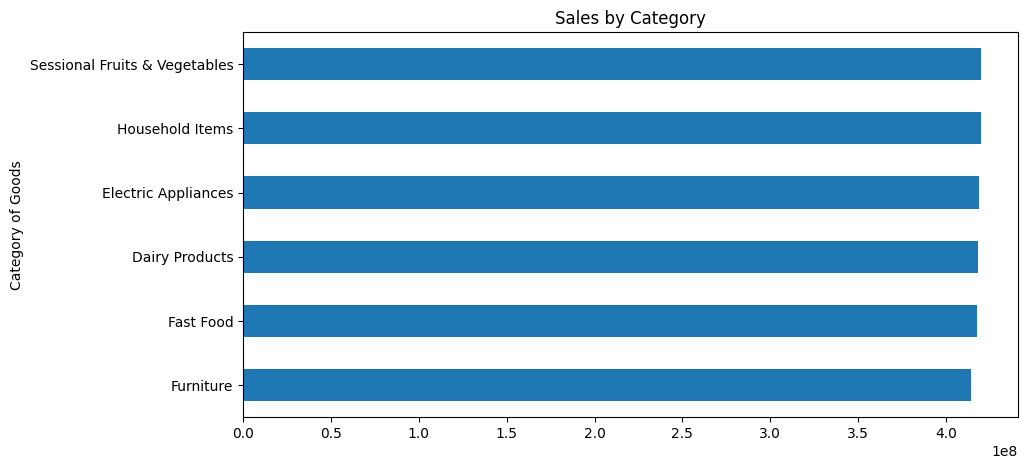

In [19]:
# -----------------------------
# Sales by Category
# -----------------------------
plt.figure(figsize=(10,5))

sales_category = (
    df.groupby("Category of Goods")["Sales"]
    .sum()
    .sort_values()
)

sales_category.plot(kind="barh")

plt.title("Sales by Category")
plt.show()

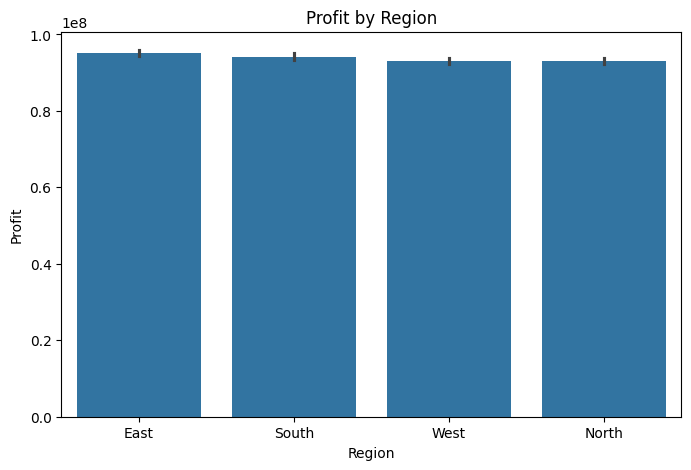

In [20]:
# -----------------------------
# Profit by Region
# -----------------------------
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Profit",
    estimator=sum
)

plt.title("Profit by Region")
plt.show()

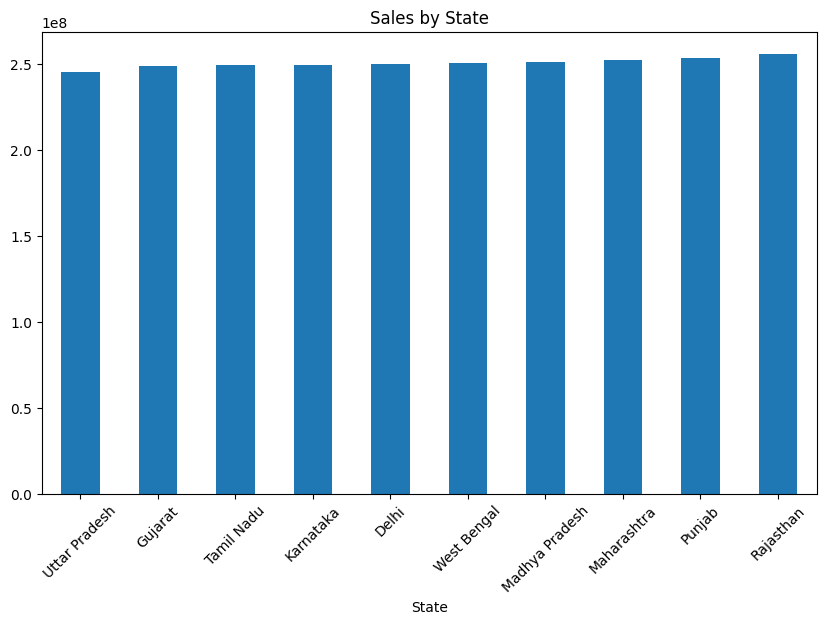

In [21]:
# -----------------------------
# Sales by State
# -----------------------------
plt.figure(figsize=(10,6))

sales_state = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values()
)

sales_state.plot(kind="bar")

plt.title("Sales by State")
plt.xticks(rotation=45)
plt.show()

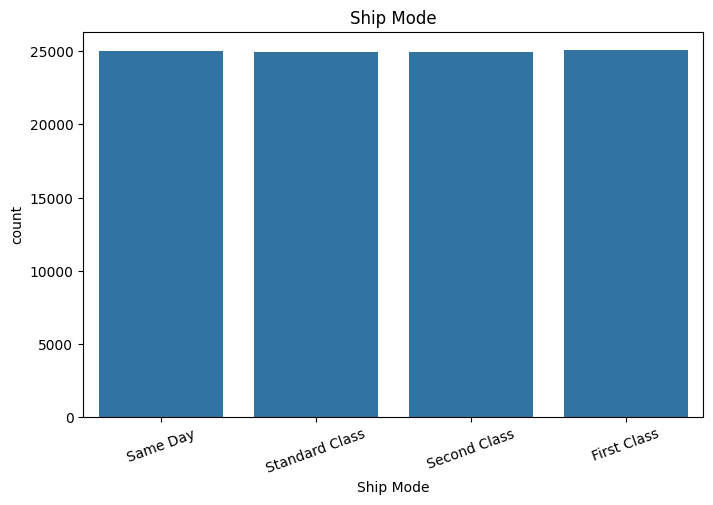

In [22]:
# -----------------------------
# Ship Mode Analysis
# -----------------------------
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Ship Mode"
)

plt.xticks(rotation=20)

plt.title("Ship Mode")
plt.show()

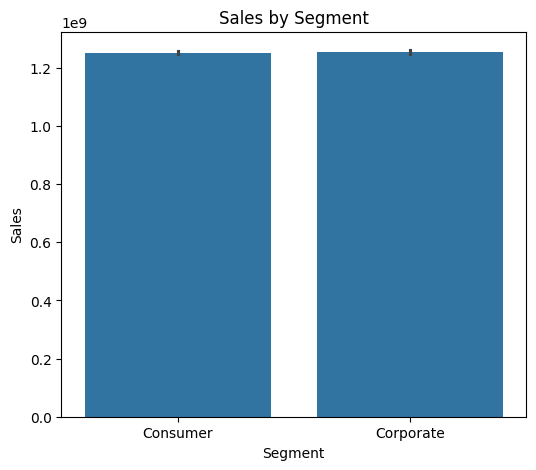

In [23]:
# -----------------------------
# Segment Analysis
# -----------------------------
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="Segment",
    y="Sales",
    estimator=sum
)

plt.title("Sales by Segment")
plt.show()

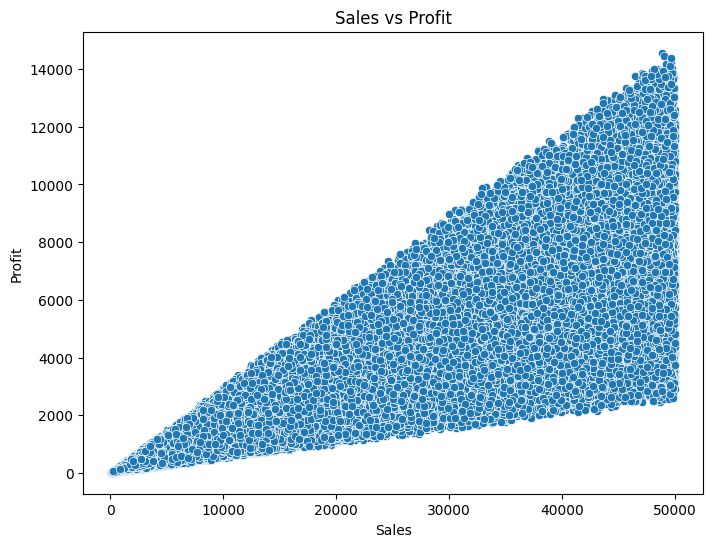

In [24]:
# -----------------------------
# Sales vs Profit
# -----------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")
plt.show()

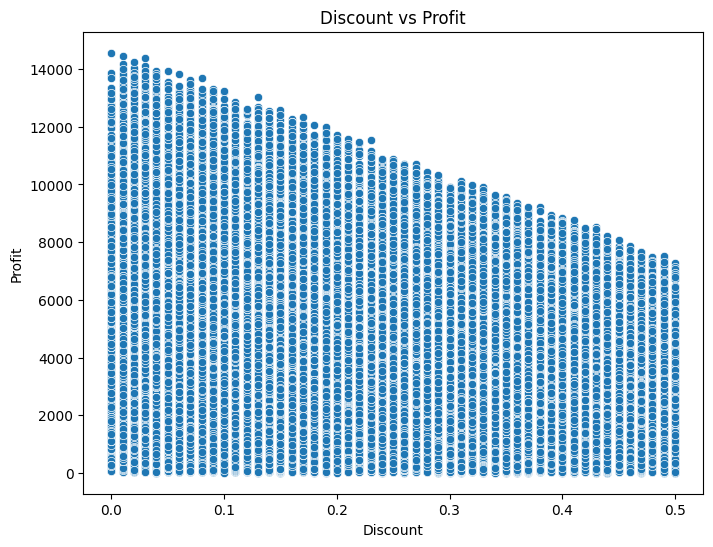

In [25]:
# -----------------------------
# Discount vs Profit
# -----------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.show()

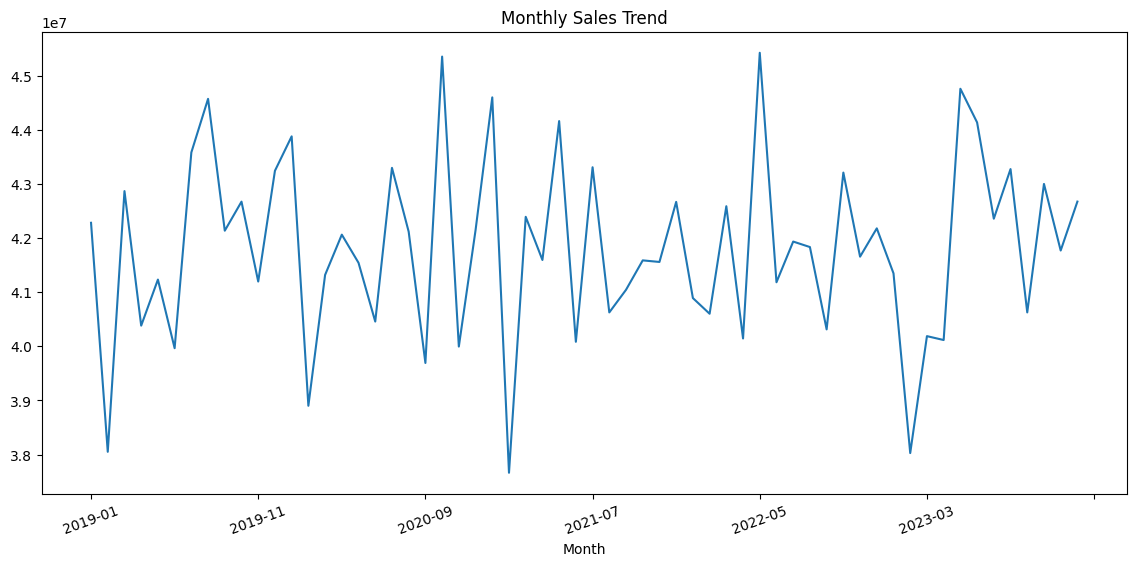

In [27]:
# -----------------------------
# Monthly Sales Trend
# -----------------------------
df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xticks(rotation=20)

plt.show()

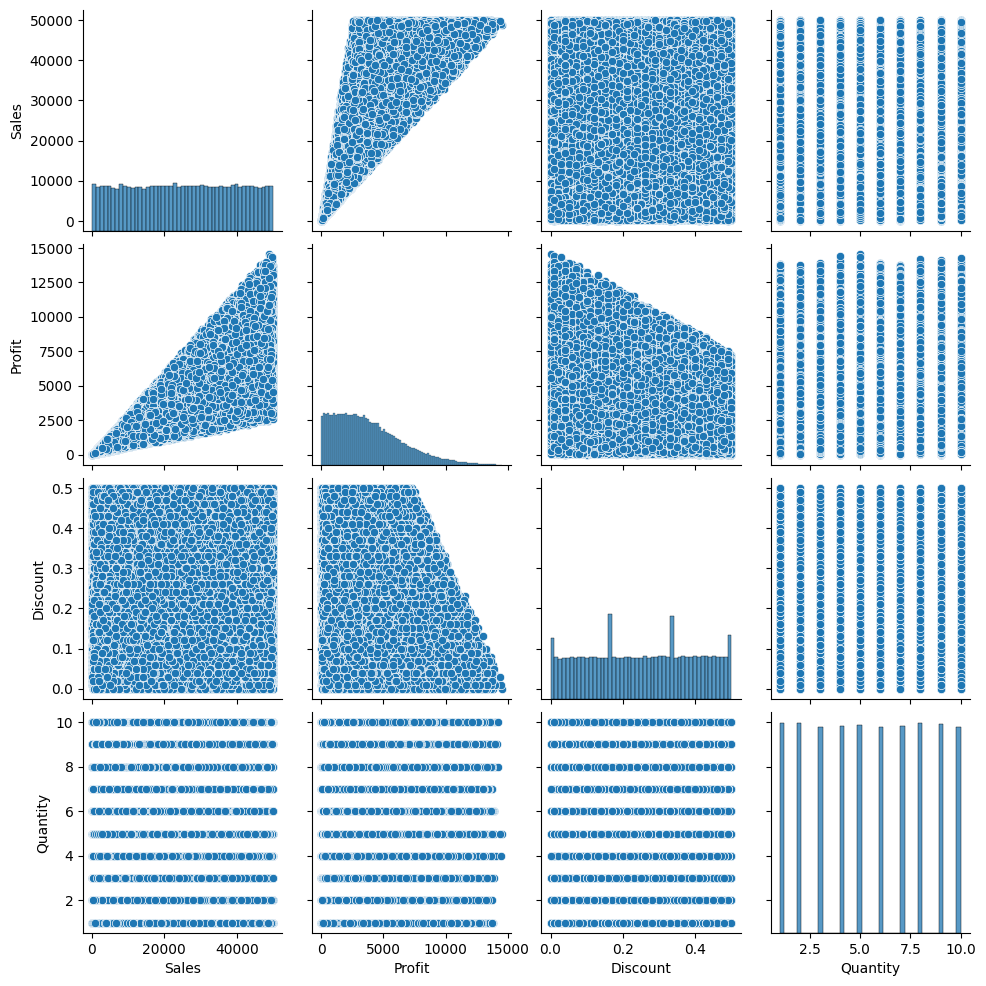


Advanced EDA Completed Successfully.


In [28]:
# -----------------------------
# Pair Plot
# -----------------------------
sns.pairplot(
    df[
        ["Sales",
         "Profit",
         "Discount",
         "Quantity"]
    ]
)

plt.show()

print("\nAdvanced EDA Completed Successfully.")